# PIPELINE

## Lectura de archivos

In [38]:
# Librerías
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

df = pd.read_excel("Motor Trend Car Road Tests.xlsx")

# Quitar la columna con el nombre de cada automóvil
df = df.drop(columns=["model"])
df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


## Análisis exploratorio de datos (EDA)

Primero se revisa el tamaño del dataset, el significado general de sus variables y el tipo de dato con el que fueron leídas. En este caso, `mpg` representa el rendimiento del automóvil en millas por galón y se tomará como la variable que se busca comprender.

In [39]:
# Tamaño, variables y tipos de datos

print("Número de automóviles:", df.shape[0])
print("Número de variables:", df.shape[1])
print("\nVariables del dataset:")
print(df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)

Número de automóviles: 32
Número de variables: 11

Variables del dataset:
['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb']

Tipos de datos:
mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object


### Clasificación de las variables

Las variables `mpg`, `disp`, `hp`, `drat`, `wt` y `qsec` son numéricas. Por otro lado, `cyl`, `vs`, `am`, `gear` y `carb` aparecen como números, pero también pueden analizarse como variables discretas o categorías porque representan cantidades o grupos específicos. La columna `model` fue eliminada con `drop` debido a que únicamente identificaba el nombre de cada automóvil.

In [40]:
# Valores faltantes y filas duplicadas

calidad = pd.DataFrame({
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje faltante": (df.isnull().mean() * 100).round(2),
    "Valores únicos": df.nunique()
})

display(calidad)
print("Filas duplicadas:", df.duplicated().sum())

,Valores faltantes,Porcentaje faltante,Valores únicos
mpg,0,0.0,25
cyl,0,0.0,3
disp,0,0.0,27
hp,0,0.0,22
drat,0,0.0,22
wt,0,0.0,29
qsec,0,0.0,30
vs,0,0.0,2
am,0,0.0,2
gear,0,0.0,3


Filas duplicadas: 0


El dataset contiene 32 automóviles diferentes. No hay valores faltantes ni filas duplicadas.

## Separación de las columnas

`mpg` será la variable de respuesta. Las demás columnas se separan según el tipo de información que contienen para poder aplicarles después el tratamiento correspondiente dentro del pipeline.

In [41]:
# Variable de respuesta y grupos de factores

target_col = ["mpg"]
numerical_cols = ["disp", "hp", "drat", "wt", "qsec"]
categorical_cols = ["cyl", "gear", "carb"]
boolean_cols = ["vs", "am"]

X = df.drop(columns=target_col)
y = df[target_col]

print("Variable de respuesta:", target_col)
print("Columnas numéricas:", numerical_cols)
print("Columnas categóricas:", categorical_cols)
print("Columnas booleanas:", boolean_cols)
print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Variable de respuesta: ['mpg']
Columnas numéricas: ['disp', 'hp', 'drat', 'wt', 'qsec']
Columnas categóricas: ['cyl', 'gear', 'carb']
Columnas booleanas: ['vs', 'am']
Tamaño de X: (32, 10)
Tamaño de y: (32, 1)


## Preprocesamiento de las columnas

Las variables numéricas se estandarizan, las categóricas se convierten en columnas de ceros y unos, y las booleanas pasan sin cambios.

In [42]:
# Transformadores para cada grupo de columnas

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("bool", "passthrough", boolean_cols)
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

## Modelo dentro del pipeline

El pipeline aplica primero el tratamiento correspondiente a cada tipo de columna y después utiliza los datos transformados para ajustar la regresión lineal.

In [43]:
# Modelo de regresión lineal

model = LinearRegression()

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['cyl','disp','hp',...,'am','gear','carb']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the

In [44]:
# Para acceder al modelo entrenado dentro del pipeline
pipeline["model"].coef_

array([[ 4.33618166, -4.75801768,  0.62247393, -4.36239021,  0.64696571,
         0.99495275, -1.65374252,  0.65878977, -1.21425031, -0.09989537,
         1.31414568, -2.4732813 , -3.45263562,  0.52635745, -1.38185841,
         2.00428791,  4.77712996,  1.93085054,  1.2121157 ]])

In [45]:
# Obtener el R² del pipeline
pipeline.score(X, y)

0.8930749320864843

## Predicciones y residuos

El residuo se calcula restando la predicción al valor observado, es decir, $e = y - \hat{y}$.

,y observada,y predicha,residuo
0,21.0,21.379742,-0.379742
1,21.0,20.430642,0.569358
2,22.8,26.308729,-3.508729
3,21.4,20.807279,0.592721
4,18.7,17.425801,1.274199


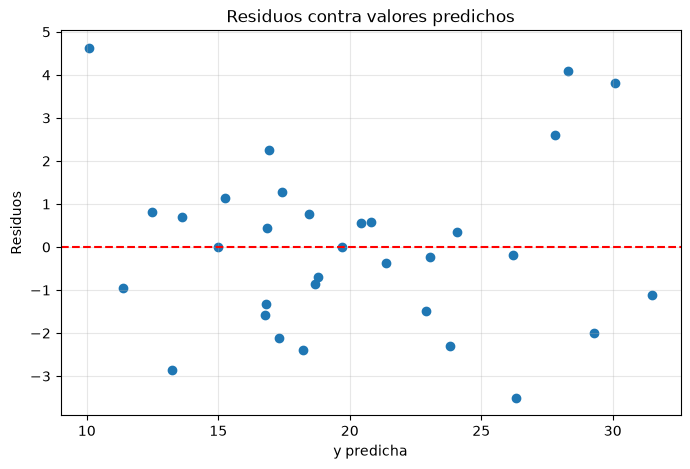

In [46]:
# Obtener la y predicha y calcular los residuos

y_pred = pipeline.predict(X).ravel()
y_real = y["mpg"].to_numpy()
residuos = y_real - y_pred

resultados = pd.DataFrame({
    "y observada": y_real,
    "y predicha": y_pred,
    "residuo": residuos
})

display(resultados.head())

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuos)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("y predicha")
plt.ylabel("Residuos")
plt.title("Residuos contra valores predichos")
plt.grid(alpha=0.3)
plt.show()